# Sentiment Intensity Prediction Model

This notebook trains a regression model to predict the intensity of sentiment expressed in customer reviews. 
Star ratings (1–5) are blended with VADER text sentiment scores to create a continuous intensity scale (–1 to +1), where:

* **–1.0** = Strongest negative sentiment (1 star)
* **0.0** = Neutral sentiment (3 stars)
* **+1.0** = Strongest positive sentiment (5 stars)

**Model Type:** Ridge Regression with TF-IDF Vectorization  
**Note:** Requires `pip install vaderSentiment`



In [2]:
pip install vaderSentiment

Note: you may need to restart the kernel to use updated packages.


# Imports 

In [3]:
# Importing necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Initialize VADER sentiment analyzer
# VADER is a rule-based sentiment tool that returns a compound score between -1 and +1
analyzer = SentimentIntensityAnalyzer()
print('Imports complete.')

Imports complete.


# Intensity Mapping Function

In [4]:
def map_stars_to_intensity(stars):
    """
    Convert star ratings to a continuous sentiment intensity score.

    Converts a 1–5 star rating into a –1 to +1 intensity scale
    using the formula: (stars - 3) / 2

    Parameters:
        stars (int): Star rating from 1 to 5

    Returns:
        float: Intensity score between –1.0 and +1.0
    """
    return (stars - 3) / 2


def get_continuous_intensity(text, stars):
    """
    Blend star rating score (60%) with VADER text sentiment score (40%).

    Using only star ratings produces just 5 fixed values (-1, -0.5, 0, 0.5, 1)
    which limits model learning. Blending with VADER creates unique continuous
    scores per review (e.g. 0.732, -0.481) giving the model a richer signal to learn from.

    Parameters:
        text (str): Review text
        stars (int): Star rating from 1 to 5

    Returns:
        float: Blended intensity score between –1.0 and +1.0
    """
    star_score  = map_stars_to_intensity(stars)
    vader_score = analyzer.polarity_scores(str(text))['compound']
    blended     = 0.6 * star_score + 0.4 * vader_score
    return float(np.clip(blended, -1.0, 1.0))


def map_intensity_to_label(score):
    """
    Convert a predicted intensity score to a human-readable intensity label.
    Used only for display purposes — the model always outputs a float score.

    Parameters:
        score (float): Predicted intensity score between –1.0 and +1.0

    Returns:
        str: Intensity label
    """
    if score <= -0.6:   return 'Strong Negative'
    elif score <= -0.2: return 'Negative'
    elif score <= 0.2:  return 'Neutral'
    elif score <= 0.6:  return 'Positive'
    else:               return 'Strong Positive'


print('Functions ready.')

Functions ready.


# Data Loading and Preprocessing

In [5]:
# Load the cleaned dataset 
df = pd.read_csv('training_testing_dataset.csv')

print(f'Total samples: {len(df)}')
print('Computing continuous intensity scores (may take 2-4 minutes)...')

# Generate blended intensity scores by combining star ratings and VADER text scores
# This creates unique continuous values per review instead of just 5 fixed values
df['intensity_score'] = df.apply(
    lambda row: get_continuous_intensity(row['clean_text'], row['stars']),
    axis=1
)

# Separate features (review text) and target (intensity score)
content   = df['clean_text']        # Review text content
intensity = df['intensity_score']   # Continuous blended intensity score

print(f'Done.')
print(f'Unique score values : {intensity.nunique()}')
print(f'Score range         : {intensity.min():.4f} to {intensity.max():.4f}')
print(f'\nIntensity distribution:')
print(df['intensity_score'].apply(map_intensity_to_label).value_counts())

Total samples: 14990
Computing continuous intensity scores (may take 2-4 minutes)...
Done.
Unique score values : 8939
Score range         : -0.9988 to 0.9997

Intensity distribution:
intensity_score
Strong Positive    6034
Strong Negative    3079
Negative           2249
Positive           2057
Neutral            1571
Name: count, dtype: int64


# Train-Test Split

In [6]:
# Split dataset: 80% training, 20% testing
content_train, content_test, intensity_train, intensity_test = train_test_split(
    content,
    intensity,
    test_size=0.2,        # 20% reserved for model testing
    random_state=2016     # Fixed seed for reproducible results
)

print(f'Dataset Split:')
print(f'  Training samples : {len(content_train)}')
print(f'  Test samples     : {len(content_test)}')

Dataset Split:
  Training samples : 11992
  Test samples     : 2998


# Text Vectorization (TF-IDF)

In [7]:
# Convert text into numerical features using TF-IDF (Term Frequency-Inverse Document Frequency)
# This captures the importance of words relative to their frequency across all reviews
vectorizer = TfidfVectorizer(
    max_features=12000,     # Use top 12,000 most significant terms
    ngram_range=(1, 3),     # Include single words, two-word and three-word phrases
    min_df=2,               # Exclude rare terms (appearing in fewer than 2 reviews)
    max_df=0.85,            # Exclude common terms (appearing in more than 85% of reviews)
    sublinear_tf=True       # Apply log normalization to reduce impact of very frequent words
)

# Transform training data and learn vocabulary
content_train_tfidf = vectorizer.fit_transform(content_train)

# Transform test data using the same vocabulary (no additional learning)
content_test_tfidf  = vectorizer.transform(content_test)

print(f'Text Vectorization:')
print(f'  Feature matrix shape : {content_train_tfidf.shape}')
print(f'  Vocabulary size      : {len(vectorizer.vocabulary_)} unique terms')

Text Vectorization:
  Feature matrix shape : (11992, 12000)
  Vocabulary size      : 12000 unique terms


# Model Training

In [8]:
# Initialize Ridge Regression model
# Ridge is well suited for high-dimensional TF-IDF features
# alpha controls regularization strength (higher = stronger regularization)
model = Ridge(
    alpha=1.0,            # Regularization strength
    random_state=2016     # Fixed seed for reproducibility
)

# Train the model on vectorized training data
model.fit(content_train_tfidf, intensity_train)

print(f'Model Configuration:')
print(f'  Algorithm : {type(model).__name__}')
print(f'  Alpha     : 1.0')
print('  Model training complete.')

Model Configuration:
  Algorithm : Ridge
  Alpha     : 1.0
  Model training complete.


# Model Evaluation

We evaluate the regression models using the following metrics:

* **MAE (Mean Absolute Error)** — shows the average difference between the actual and predicted intensity values (lower is better)
* **RMSE (Root Mean Squared Error)** — similar to MAE, but gives more importance to larger errors (lower is better)
* **R² Score** — shows how well the model fits the data overall (higher is better, max = 1.0)

In [9]:
# Generate predictions on the test set and clip to valid range [-1, 1]
predictions = np.clip(model.predict(content_test_tfidf), -1, 1)

# Calculate performance metrics
mae  = mean_absolute_error(intensity_test, predictions)
rmse = np.sqrt(mean_squared_error(intensity_test, predictions))
r2   = r2_score(intensity_test, predictions)

print('MODEL PERFORMANCE METRICS')
print('=' * 50)
print(f'  MAE  : {mae:.4f}  (avg prediction error in intensity units)')
print(f'  RMSE : {rmse:.4f}')
print(f'  R²   : {r2:.4f}')
print(f'  Total predictions made: {len(predictions)}')

MODEL PERFORMANCE METRICS
  MAE  : 0.2627  (avg prediction error in intensity units)
  RMSE : 0.3372
  R²   : 0.7518
  Total predictions made: 2998


# Intensity Label Conversion

In [10]:
# Convert continuous intensity scores to labels for heatmap visualization
actual_labels = [map_intensity_to_label(s) for s in intensity_test.values]
pred_labels   = [map_intensity_to_label(s) for s in predictions]

# Define label order for consistent axis display
label_order  = ['Strong Negative', 'Negative', 'Neutral', 'Positive', 'Strong Positive']

# Build confusion matrix from intensity labels
cm = pd.crosstab(
    pd.Categorical(actual_labels, categories=label_order),
    pd.Categorical(pred_labels,   categories=label_order),
    rownames=['Actual'],
    colnames=['Predicted']
)

print('Intensity label conversion complete.')

Intensity label conversion complete.


# Intensity Heatmap

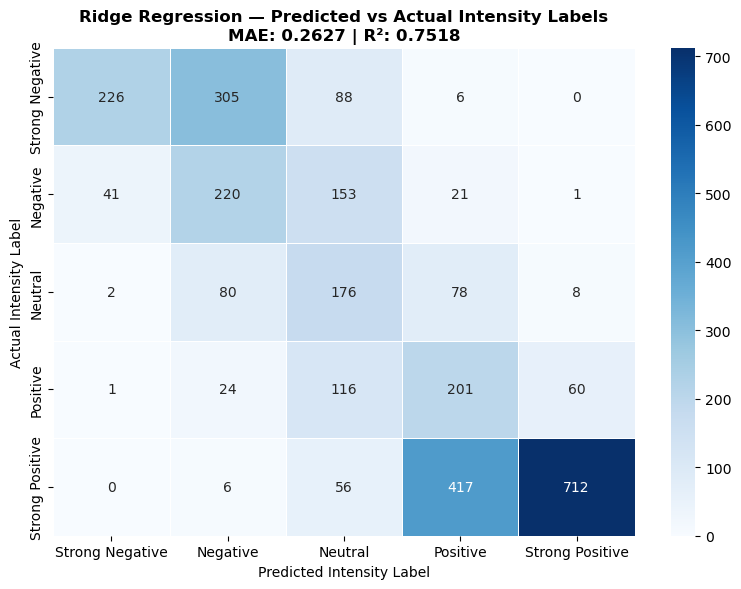

In [13]:
# Visualizing predicted vs actual intensity labels across all intensity levels
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=0.5,
            xticklabels=label_order, yticklabels=label_order)
plt.title(f'Ridge Regression — Predicted vs Actual Intensity Labels\nMAE: {mae:.4f} | R²: {r2:.4f}',
          fontsize=12, fontweight='bold')
plt.xlabel('Predicted Intensity Label')
plt.ylabel('Actual Intensity Label')
plt.tight_layout()
plt.show()

# Saving Model Predictions Sample 

In [14]:
# Build predictions dataframe with intensity scores and human-readable labels
predictions_df = pd.DataFrame({
    'text':                      content_test.values,
    'actual_intensity_score':    intensity_test.values,
    'predicted_intensity_score': predictions,
    'predicted_intensity_label': pred_labels
})

# Save predictions to CSV
predictions_df.to_csv('intensity_predicted_data.csv', index=False)
print(f'Predictions saved to intensity_predicted_data.csv')
print(f'Total predictions: {len(predictions_df)}')
print(f'\nPredicted Intensity Label Distribution:')
print(predictions_df['predicted_intensity_label'].value_counts())
print('\nSample predictions (first 10 rows):')
predictions_df.head(10)

Predictions saved to intensity_predicted_data.csv
Total predictions: 2998

Predicted Intensity Label Distribution:
predicted_intensity_label
Strong Positive    781
Positive           723
Negative           635
Neutral            589
Strong Negative    270
Name: count, dtype: int64

Sample predictions (first 10 rows):


,text,actual_intensity_score,predicted_intensity_score,predicted_intensity_label
0,worst morning service ever. rude! my drink is ...,-0.92488,-0.710603,Strong Negative
1,"this is an ok starbucks, but the job got done....",0.38544,0.445447,Positive
2,slowly but surely i'm going back into a normal...,0.99928,0.662523,Strong Positive
3,had to have my daily starbucks! it's not for l...,0.97428,0.483894,Positive
4,"they used to be so great, now the cafe is cons...",-0.00700,-0.104702,Neutral
5,i visit this starbucks a couple times a week--...,-0.19936,-0.292706,Negative
6,one of my favorite starbucks around. lots of p...,0.96896,1.000000,Strong Positive
7,i like this starbucks because it's generally l...,0.53204,0.141740,Neutral
8,i love starbucks. loyal customer since their f...,0.05640,-0.008284,Neutral
9,great location. friendly people. they remember...,0.97252,1.000000,Strong Positive


# Vocabulary Data with Intensity Associations

In [15]:
# Build vocabulary dataframe with intensity associations
# Shows which words push sentiment toward positive (+) or negative (-)
feature_names = vectorizer.get_feature_names_out()
vocab_data    = []

for idx, feature in enumerate(feature_names):
    # Get TF-IDF average importance
    tfidf_value = content_train_tfidf.mean(axis=0).A1[idx]

    # Get coefficient for this feature
    # Positive coefficient = word pushes toward positive intensity
    # Negative coefficient = word pushes toward negative intensity
    coefficient = model.coef_[idx]

    vocab_data.append({
        'Word/Phrase':           feature,
        'TF-IDF_Average':        tfidf_value,
        'Intensity_Coefficient': coefficient
    })

vocab_dataframe = pd.DataFrame(vocab_data)
vocab_dataframe = vocab_dataframe.sort_values(by=['Intensity_Coefficient'], ascending=False)

# Save vocab data to CSV
vocab_dataframe.to_csv('intensity_vocab_data.csv', index=False)
print(f'Vocabulary data saved to intensity_vocab_data.csv')
print(f'Total terms: {len(vocab_dataframe)}')
print('\nSample (first 10 rows):')
vocab_dataframe.head(10)

Vocabulary data saved to intensity_vocab_data.csv
Total terms: 12000

Sample (first 10 rows):


,Word/Phrase,TF-IDF_Average,Intensity_Coefficient
3725,great,0.012795,2.122399
3371,friendly,0.013762,1.646529
5528,love,0.008532,1.608884
345,amazing,0.003015,1.557638
1451,best,0.005935,1.287334
6235,nice,0.010136,1.285086
2925,excellent,0.002174,1.228932
1166,awesome,0.003276,1.213997
3345,free,0.003987,1.199089
3654,good,0.011469,1.129542


# Exporting the Model and Vectorizer

In [17]:
# Save the trained model
joblib.dump(model, 'sentiment_intensity_model.pkl')

# Save the vectorizer
joblib.dump(vectorizer, 'intensity_tfidf_vectorizer.pkl')

print("Ridge Regression model saved to sentiment_intensity_model.pkl")
print("Vectorizer saved to intensity_tfidf_vectorizer.pkl")

Ridge Regression model saved to sentiment_intensity_model.pkl
Vectorizer saved to intensity_tfidf_vectorizer.pkl
